In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import sys; sys.path.insert(0, '.')
from feature_engineering import add_trend_features

In [2]:
# Consistent model ordering -- precision weights computed dynamically in backtest cell
MODEL_KEYS = [
    'XGBoost no-rec', 'XGBoost with-rec',
    'RF no-rec',       'RF with-rec',
    'Ridge no-rec',    'Lasso no-rec',  'Linear no-rec',
    'Ridge with-rec',  'Lasso with-rec', 'Linear with-rec',
]
print(f"Models ({len(MODEL_KEYS)}):", MODEL_KEYS)

Models (10): ['XGBoost no-rec', 'XGBoost with-rec', 'RF no-rec', 'RF with-rec', 'Ridge no-rec', 'Lasso no-rec', 'Linear no-rec', 'Ridge with-rec', 'Lasso with-rec', 'Linear with-rec']


In [3]:
df_full  = pd.read_csv('data/dataset.csv',
                       parse_dates=['Date']).set_index('Date').sort_index()
df_norec = pd.read_csv('data/dataset-no-recessions.csv',
                       parse_dates=['Date']).set_index('Date').sort_index()

df_full  = add_trend_features(df_full)
df_norec = add_trend_features(df_norec)

current_spread = df_full['BAA10Y'].dropna().iloc[-1]
current_date   = df_full['BAA10Y'].dropna().index[-1]
target_date    = current_date + pd.Timedelta(days=1)   # the date being predicted
target_date    = pd.Timestamp("2026-05-16")                   # override for verification

print(f"Full dataset:   {len(df_full):,} rows  ({df_full.index[0].date()} to {df_full.index[-1].date()})")
print(f"No-rec dataset: {len(df_norec):,} rows")
print(f"\nCurrent BAA10Y spread: {current_spread:.4f}  (as of {current_date.date()})")
print(f"Predicting target date: {target_date.date()}  (tomorrow)")
print()
for H in [1, 7, 28]:
    pred_input = target_date - pd.Timedelta(days=H)
    print(f"  H={H:2d}: prediction input row = {pred_input.date()}  (target {target_date.date()} = {pred_input.date()} + {H}d)")

Full dataset:   13,287 rows  (1990-01-01 to 2026-05-18)
No-rec dataset: 11,825 rows

Current BAA10Y spread: 1.6200  (as of 2026-05-18)
Predicting target date: 2026-05-16  (tomorrow)

  H= 1: prediction input row = 2026-05-15  (target 2026-05-16 = 2026-05-15 + 1d)
  H= 7: prediction input row = 2026-05-09  (target 2026-05-16 = 2026-05-09 + 7d)
  H=28: prediction input row = 2026-04-18  (target 2026-05-16 = 2026-04-18 + 28d)


In [4]:
TRAIN_YEARS = 30
ALPHAS      = [1.0, 0.1, 0.01, 0.001, 0.0001, 0.00001]
RF_N        = 500   # near-optimal per OOB curves, avoids 20+ min runtime


def _prep_Xy(df, H):
    y_future = df['BAA10Y'].shift(-H)
    y_now    = df['BAA10Y']
    X_full   = df.drop(columns=['BAA10Y']).copy()
    X_full['BAA10Y_current'] = df['BAA10Y']
    return X_full, y_future, y_now


def build_train_pred(df, H, strict=False, target_date=None):
    """
    Build training set and prediction input row.

    For horizon H predicting target_date, the prediction input row is
    the state H days before target_date (so model's H-day output lands on target_date).
    Training covers the 30 years before that input date.
    """
    X_full, y_future, y_now = _prep_Xy(df, H)

    if target_date is None:
        target_date = df['BAA10Y'].dropna().index[-1] + pd.Timedelta(days=1)

    # Prediction input: the state H days before the target
    pred_input_date = target_date - pd.Timedelta(days=H)
    train_start     = pred_input_date - pd.DateOffset(years=TRAIN_YEARS)

    if strict:
        mask = y_future.notna() & y_now.notna() & X_full.notna().all(axis=1)
    else:
        mask = y_future.notna() & y_now.notna()

    date_mask = mask & (df.index >= train_start) & (df.index <= pred_input_date)
    X_train   = X_full.loc[date_mask]
    y_train   = y_future.loc[date_mask]

    # Get the latest valid row at or before pred_input_date
    pred_mask = X_full.notna().all(axis=1) & y_now.notna() & (df.index <= pred_input_date)
    X_pred    = X_full.loc[pred_mask].iloc[-1:]
    return X_train, y_train, X_pred


def build_backtest(df, H, strict_train=False,
                   cutoff=pd.Timestamp('2025-09-30'),
                   test_start=pd.Timestamp('2025-10-01'),
                   test_end=pd.Timestamp('2025-12-31')):
    """Backtest: train up to cutoff, evaluate on known test window."""
    X_full, y_future, y_now = _prep_Xy(df, H)
    train_start = cutoff - pd.DateOffset(years=TRAIN_YEARS)
    if strict_train:
        train_mask = (y_future.notna() & y_now.notna() & X_full.notna().all(axis=1)
                      & (df.index >= train_start) & (df.index <= cutoff))
    else:
        train_mask = (y_future.notna() & y_now.notna()
                      & (df.index >= train_start) & (df.index <= cutoff))
    # Test rows: all features valid + outcome known
    test_mask = (X_full.notna().all(axis=1) & y_now.notna() & y_future.notna()
                 & (df.index >= test_start) & (df.index <= test_end))
    return (X_full.loc[train_mask], y_future.loc[train_mask],
            X_full.loc[test_mask],  y_future.loc[test_mask], y_now.loc[test_mask])


print("Helpers defined: build_train_pred, build_backtest")

Helpers defined: build_train_pred, build_backtest


In [5]:
# -- Model fitting functions (used by both backtest and production cells) -------
def fit_xgb_sweep(X_tr, y_tr, X_pred):
    """XGBoost with early stopping on training data. Returns (predictions, best_n)."""
    val_cut = int(len(X_tr) * 0.8)
    sweep = xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        early_stopping_rounds=50, eval_metric='rmse', random_state=42,
    )
    sweep.fit(X_tr.iloc[:val_cut], y_tr.iloc[:val_cut],
              eval_set=[(X_tr.iloc[val_cut:], y_tr.iloc[val_cut:])], verbose=False)
    best_n = sweep.best_iteration
    model  = xgb.XGBRegressor(
        n_estimators=best_n, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
    )
    model.fit(X_tr, y_tr)
    return model.predict(X_pred), best_n


def fit_rf(X_tr, y_tr, X_pred, n_estimators=RF_N):
    model = RandomForestRegressor(
        n_estimators=n_estimators, bootstrap=True, n_jobs=-1, random_state=42,
    )
    model.fit(X_tr, y_tr)
    return model.predict(X_pred)


def fit_linear(X_tr, y_tr, X_pred):
    """Returns dict {'Ridge': arr, 'Lasso': arr, 'Linear': arr}."""
    scaler    = StandardScaler()
    X_tr_sc   = scaler.fit_transform(X_tr)
    X_pred_sc = scaler.transform(X_pred)
    val_cut   = int(len(X_tr_sc) * 0.8)
    best_alpha, best_mse = ALPHAS[0], np.inf
    for alpha in ALPHAS:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m = Lasso(alpha=alpha, max_iter=10000)
            m.fit(X_tr_sc[:val_cut], y_tr.iloc[:val_cut])
        mse = mean_squared_error(y_tr.iloc[val_cut:], m.predict(X_tr_sc[val_cut:]))
        if mse < best_mse:
            best_mse, best_alpha = mse, alpha
    ridge  = Ridge()
    lasso  = Lasso(alpha=best_alpha, max_iter=10000)
    linear = LinearRegression()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for m in (ridge, lasso, linear):
            m.fit(X_tr_sc, y_tr)
    return {
        'Ridge':  ridge.predict(X_pred_sc),
        'Lasso':  lasso.predict(X_pred_sc),
        'Linear': linear.predict(X_pred_sc),
    }

print("Fitting functions defined: fit_xgb_sweep, fit_rf, fit_linear")

Fitting functions defined: fit_xgb_sweep, fit_rf, fit_linear


In [6]:
# -- PHASE 1 -- TEST: Leakage-free backtest -------------------------------------
# Two fully separated windows:
#   bt_precision   : train <= Sep 2025, test Q4 2025  (weights for backtest ensemble)
#   evaluation     : train <= Dec 2025, test Q1 2026  (RMSE/DirAcc + production weights)
# Production models train to May 2026 -- completely separate.

PREC_CUTOFF  = pd.Timestamp('2025-09-30')
PREC_START   = pd.Timestamp('2025-10-01')
PREC_END     = pd.Timestamp('2025-12-31')

BT_CUTOFF    = pd.Timestamp('2025-12-31')
BT_START     = pd.Timestamp('2026-01-01')
BT_END       = pd.Timestamp('2026-03-31')

print('=== Phase 1 -- TEST ===')
print(f'  Backtest weights  : Q4 2025  ({PREC_START.date()} - {PREC_END.date()})')
print(f'  Evaluation window : Q1 2026  ({BT_START.date()}  - {BT_END.date()})')
print()


def _run_all_models(H, cutoff, test_start, test_end):
    """Fit all 10 models on [cutoff-30yr, cutoff], predict on [test_start, test_end]."""
    _, _, X_te_ref, y_actual_ref, y_curr_ref = build_backtest(
        df_norec, H, strict_train=True,
        cutoff=cutoff, test_start=test_start, test_end=test_end,
    )
    if len(X_te_ref) == 0:
        return None

    preds = {}
    for tag, df in [('no_rec', df_norec), ('with_rec', df_full)]:
        X_tr, y_tr, X_te_raw, _, _ = build_backtest(
            df, H, strict_train=False,
            cutoff=cutoff, test_start=test_start, test_end=test_end,
        )
        X_te = X_te_raw.reindex(X_te_ref.index)
        key  = 'XGBoost ' + ('no-rec' if tag == 'no_rec' else 'with-rec')
        p, _ = fit_xgb_sweep(X_tr, y_tr, X_te)
        preds[key] = p

    for tag, df in [('no_rec', df_norec), ('with_rec', df_full)]:
        X_tr, y_tr, X_te_raw, _, _ = build_backtest(
            df, H, strict_train=True,
            cutoff=cutoff, test_start=test_start, test_end=test_end,
        )
        X_te   = X_te_raw.reindex(X_te_ref.index)
        suffix = 'no-rec' if tag == 'no_rec' else 'with-rec'
        preds['RF ' + suffix] = fit_rf(X_tr, y_tr, X_te)
        for mname, p in fit_linear(X_tr, y_tr, X_te).items():
            preds[mname + ' ' + suffix] = p

    return preds, X_te_ref, y_actual_ref.values, y_curr_ref.values


def _precision_from_window(preds, y_true, y_curr):
    """Compute per-model UP/DOWN precision on a completed test window."""
    prec    = {}
    act_dir = np.sign(y_true - y_curr)
    for mname in MODEL_KEYS:
        pred_dir  = np.sign(preds[mname] - y_curr)
        said_up   = pred_dir == 1
        said_down = pred_dir == -1
        prec_up   = (act_dir[said_up]   ==  1).mean() if said_up.sum()   > 0 else 0.5
        prec_down = (act_dir[said_down] == -1).mean() if said_down.sum() > 0 else 0.5
        prec[mname] = {'up': prec_up, 'down': prec_down}
    return prec


bt_precision    = {}   # Q4 2025 -- weights for backtest ensemble
model_precision = {}   # Q1 2026 -- weights for production ensemble

rmse_by_model   = {}
diracc_by_model = {}
bt_preds_ts     = {}
bt_actual_ts    = {}
bt_dates_ts     = {}
bt_naive_ts     = {}
bt_ensemble_ts  = {}

for H in [1, 7, 28]:
    print(f'-- H={H} -------------------------------------------------------------')

    # Pass 1: Q4 2025 -- bt_precision (weights for backtest ensemble)
    prec_result = _run_all_models(H, PREC_CUTOFF, PREC_START, PREC_END)
    if prec_result is None:
        print('  Q4 2025: no test rows -- skipping'); continue
    prec_preds, _, prec_y_true, prec_y_curr = prec_result
    bt_precision[H] = _precision_from_window(prec_preds, prec_y_true, prec_y_curr)
    print(f'  Q4 2025 precision computed  (n={len(prec_y_true)})')

    # Pass 2: Q1 2026 -- evaluation + model_precision for production
    bt_result = _run_all_models(H, BT_CUTOFF, BT_START, BT_END)
    if bt_result is None:
        print('  Q1 2026: no test rows -- skipping'); continue
    preds_by_model, X_te_ref, y_true, y_curr = bt_result
    n        = len(y_true)
    act_dir  = np.sign(y_true - y_curr)
    non_flat = act_dir != 0
    nf       = non_flat.sum()
    model_precision[H] = _precision_from_window(preds_by_model, y_true, y_curr)

    rmse_by_model[H]   = {}
    diracc_by_model[H] = {}
    for mname in MODEL_KEYS:
        rmse_by_model[H][mname]   = np.sqrt(mean_squared_error(y_true, preds_by_model[mname]))
        pred_dir_m                = np.sign(preds_by_model[mname] - y_curr)
        diracc_by_model[H][mname] = (
            (act_dir[non_flat] == pred_dir_m[non_flat]).mean() if nf > 0 else np.nan
        )

    # Ensemble using bt_precision (Q4 2025 weights -- no look-ahead into Q1 2026)
    weighted_sum, total_w = np.zeros(n), np.zeros(n)
    for mname in MODEL_KEYS:
        pred_dir = np.sign(preds_by_model[mname] - y_curr)
        w = np.where(pred_dir >= 0,
                     bt_precision[H][mname]['up'],
                     bt_precision[H][mname]['down'])
        weighted_sum += preds_by_model[mname] * w
        total_w      += w
    ensemble = np.where(total_w > 0, weighted_sum / total_w, y_curr)

    rmse_ens   = np.sqrt(mean_squared_error(y_true, ensemble))
    rmse_naive = np.sqrt(mean_squared_error(y_true, y_curr))
    ens_dir    = (
        (act_dir[non_flat] == np.sign(ensemble - y_curr)[non_flat]).mean()
        if nf > 0 else np.nan
    )

    bt_preds_ts[H]     = {m: preds_by_model[m].copy() for m in MODEL_KEYS}
    bt_actual_ts[H]    = y_true.copy()
    bt_dates_ts[H]     = X_te_ref.index + pd.Timedelta(days=H)
    bt_naive_ts[H]     = y_curr.copy()
    bt_ensemble_ts[H]  = ensemble.copy()
    rmse_by_model[H]['Ensemble']   = rmse_ens
    rmse_by_model[H]['Naive']      = rmse_naive
    diracc_by_model[H]['Ensemble'] = ens_dir

    print(f'  Q1 2026 evaluation  (n={n})')
    print(f"  {'Model':22s}  {'RMSE':>7}  {'DirAcc':>7}")
    for mname in MODEL_KEYS:
        print(f"  {mname:22s}  {rmse_by_model[H][mname]:7.4f}  {diracc_by_model[H][mname]:7.2%}")
    beat = 'BETTER' if rmse_ens < rmse_naive else 'WORSE'
    print(f"  {'Ensemble':22s}  {rmse_ens:7.4f}  {ens_dir:7.2%}   (weights from Q4 2025)")
    print(f"  {'Naive':22s}  {rmse_naive:7.4f}")
    print(f'  -> Ensemble vs naive: {beat}')
    print()


=== Phase 1 -- TEST ===
  Backtest weights  : Q4 2025  (2025-10-01 - 2025-12-31)
  Evaluation window : Q1 2026  (2026-01-01  - 2026-03-31)

-- H=1 -------------------------------------------------------------
  Q4 2025 precision computed  (n=92)
  Q1 2026 evaluation  (n=90)
  Model                      RMSE   DirAcc
  XGBoost no-rec           0.0282   48.00%
  XGBoost with-rec         0.0238   56.00%
  RF no-rec                0.0208   62.00%
  RF with-rec              0.0209   62.00%
  Ridge no-rec             0.0196   56.00%
  Lasso no-rec             0.0195   50.00%
  Linear no-rec            0.0192   58.00%
  Ridge with-rec           0.0197   52.00%
  Lasso with-rec           0.0198   52.00%
  Linear with-rec          0.0191   60.00%
  Ensemble                 0.0199   54.00%   (weights from Q4 2025)
  Naive                    0.0194
  -> Ensemble vs naive: WORSE

-- H=7 -------------------------------------------------------------
  Q4 2025 precision computed  (n=92)
  Q1 2026 eva

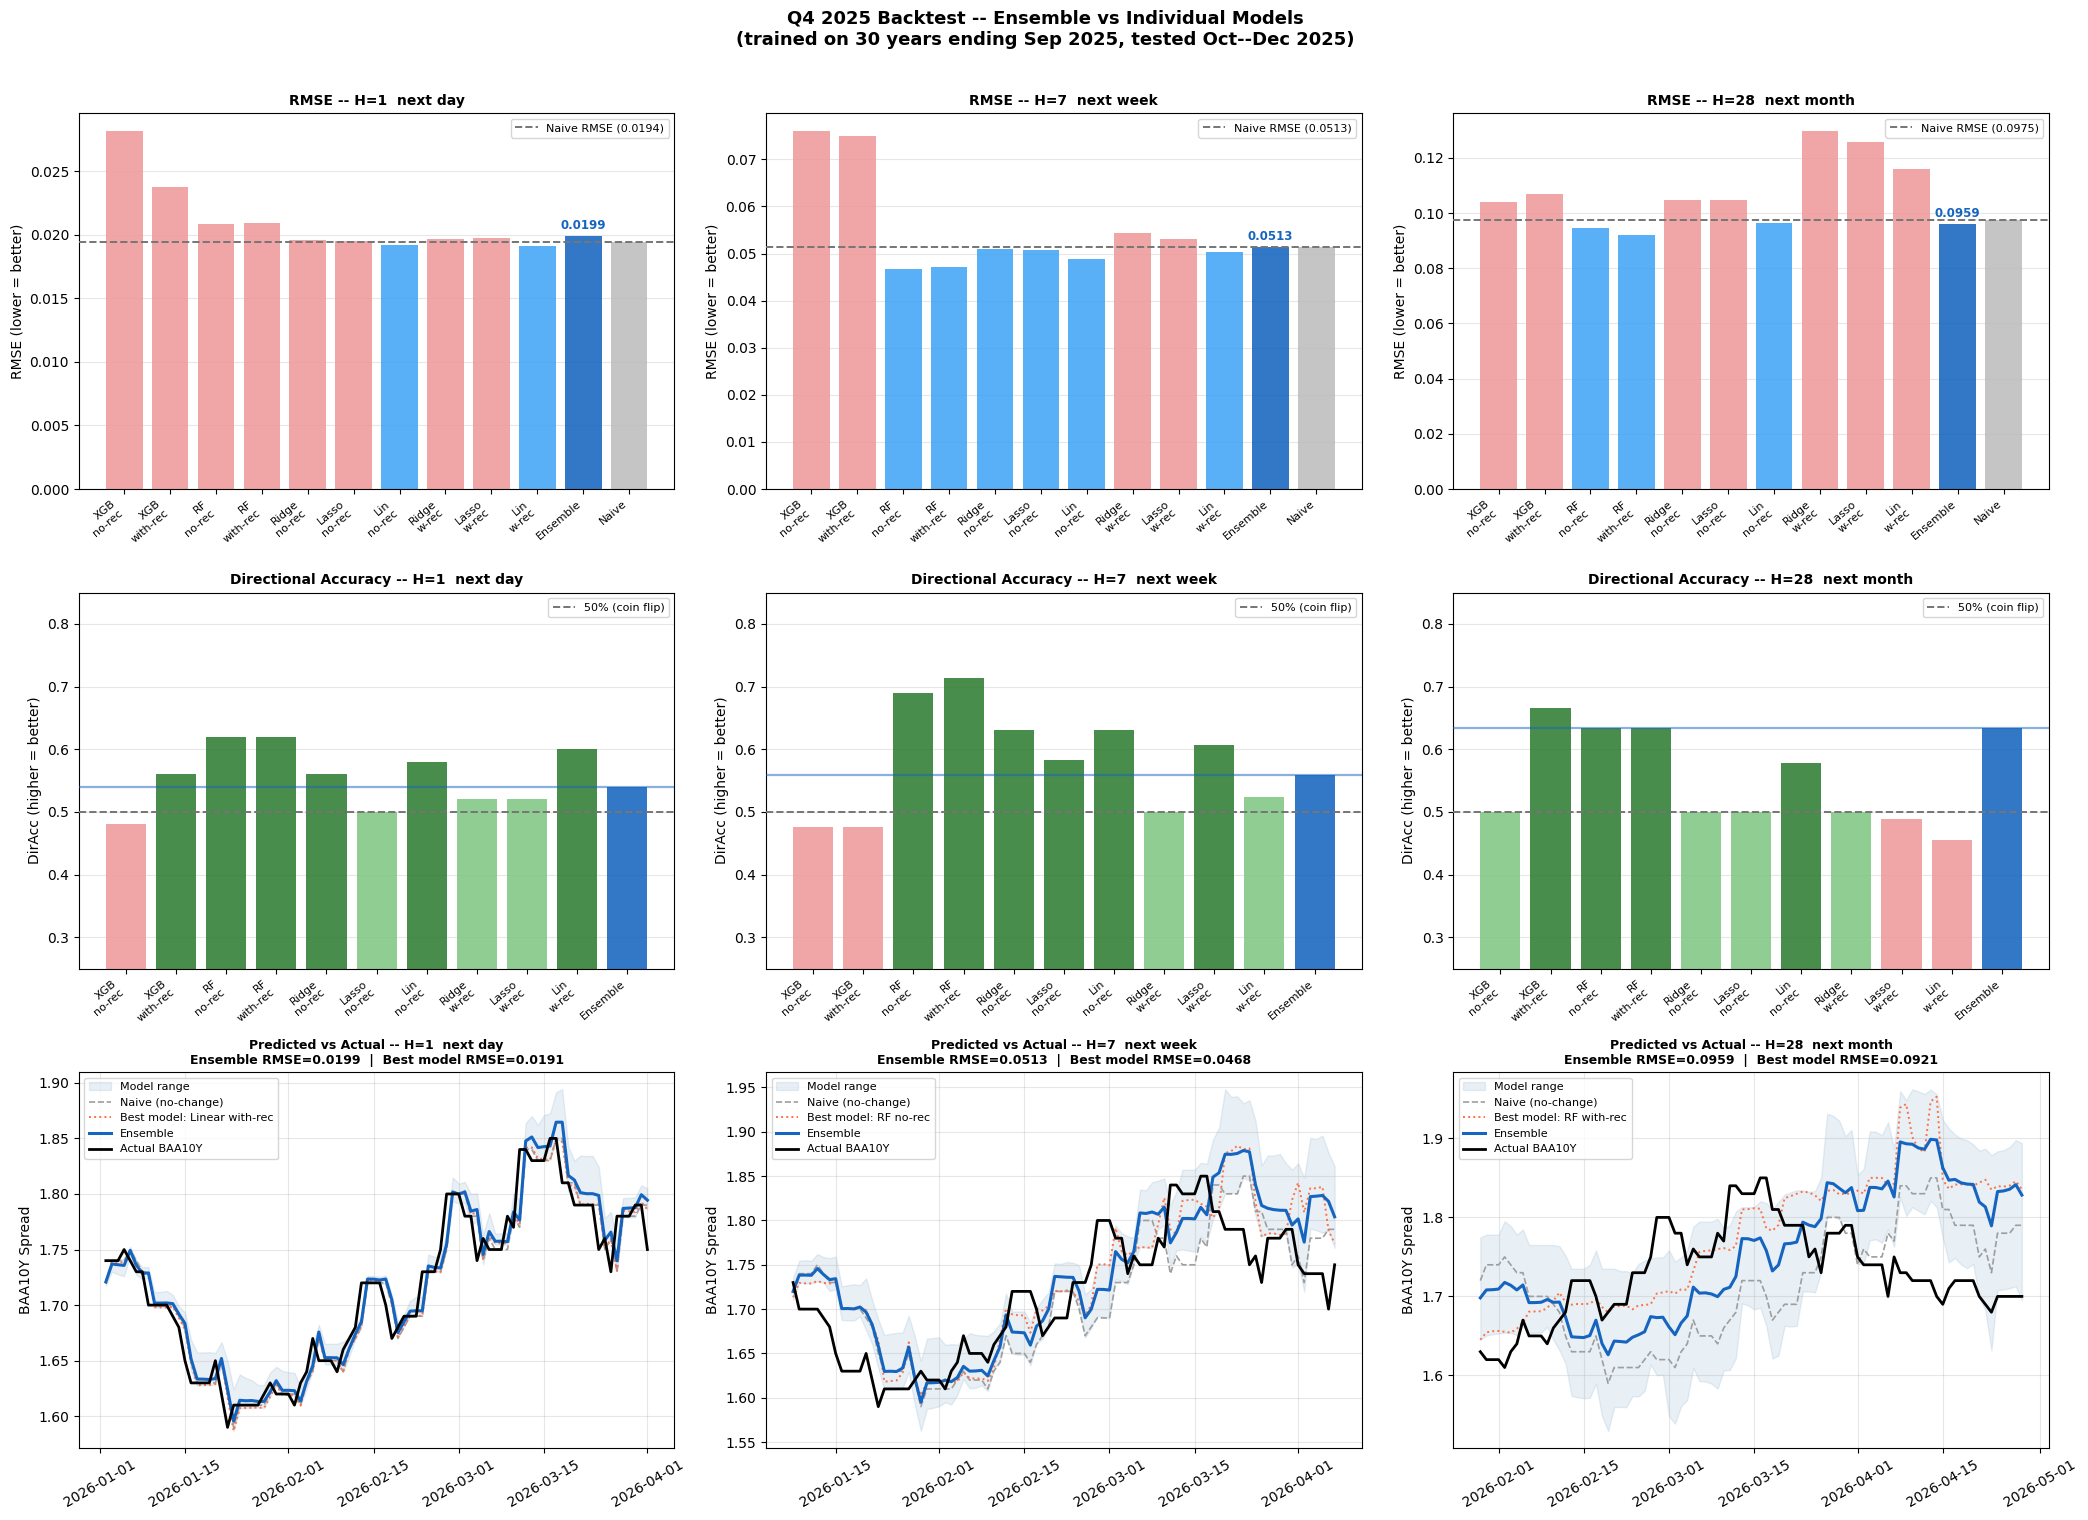

Saved: backtest_comparison.png

  BACKTEST LEADERBOARD (Q4 2025) -- sorted by RMSE

  H=1  (Naive RMSE=0.0194)
  Rank  Model                       RMSE   vs Naive    DirAcc
  ---------------------------------------------------------
      1.  Linear with-rec           0.0191    -0.0003    60.00%
      2.  Linear no-rec             0.0192    -0.0002    58.00%
      3.  Lasso no-rec              0.0195    +0.0001    50.00%
      4.  Ridge no-rec              0.0196    +0.0002    56.00%
      5.  Ridge with-rec            0.0197    +0.0003    52.00%
      6.  Lasso with-rec            0.0198    +0.0004    52.00%
  *** 7.  Ensemble                  0.0199    +0.0005    54.00% <-- ENSEMBLE
      8.  RF no-rec                 0.0208    +0.0014    62.00%
      9.  RF with-rec               0.0209    +0.0015    62.00%
     10.  XGBoost with-rec          0.0238    +0.0044    56.00%
     11.  XGBoost no-rec            0.0282    +0.0088    48.00%
       Naive                     0.0194     0.0000

In [7]:
# -- Ensemble vs Individual Models -- Comparison Dashboard ---------------------
MODEL_SHORT = [
    'XGB\nno-rec', 'XGB\nwith-rec',
    'RF\nno-rec',  'RF\nwith-rec',
    'Ridge\nno-rec', 'Lasso\nno-rec', 'Lin\nno-rec',
    'Ridge\nw-rec',  'Lasso\nw-rec',  'Lin\nw-rec',
]
H_LABELS = {1: 'H=1  next day', 7: 'H=7  next week', 28: 'H=28  next month'}

fig, axes = plt.subplots(3, 3, figsize=(21, 15))
fig.suptitle(
    'Q4 2025 Backtest -- Ensemble vs Individual Models\n'
    '(trained on 30 years ending Sep 2025, tested Oct--Dec 2025)',
    fontsize=13, fontweight='bold', y=1.01,
)

for col, H in enumerate([1, 7, 28]):
    naive_rmse = rmse_by_model[H]['Naive']

    # -- Row 0: RMSE bar chart ---------------------------------------------
    ax = axes[0, col]
    labels_rmse = MODEL_SHORT + ['Ensemble', 'Naive']
    vals_rmse   = [rmse_by_model[H][m] for m in MODEL_KEYS + ['Ensemble', 'Naive']]
    colors_rmse = []
    for i, m in enumerate(MODEL_KEYS):
        colors_rmse.append('#42A5F5' if rmse_by_model[H][m] < naive_rmse else '#EF9A9A')
    colors_rmse += ['#1565C0', '#BDBDBD']   # ensemble = dark blue, naive = grey

    bars = ax.bar(range(12), vals_rmse, color=colors_rmse, alpha=0.88, zorder=2)
    ax.axhline(naive_rmse, color='#757575', linestyle='--', linewidth=1.4,
               label=f'Naive RMSE ({naive_rmse:.4f})', zorder=3)
    # Annotate ensemble bar
    ens_v = rmse_by_model[H]['Ensemble']
    ax.annotate(
        f'{ens_v:.4f}', xy=(10, ens_v),
        xytext=(0, 5), textcoords='offset points',
        ha='center', fontsize=8.5, fontweight='bold', color='#1565C0',
    )
    ax.set_xticks(range(12))
    ax.set_xticklabels(labels_rmse, fontsize=8, rotation=40, ha='right')
    ax.set_title(f'RMSE -- {H_LABELS[H]}', fontsize=10, fontweight='bold')
    ax.set_ylabel('RMSE (lower = better)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3, zorder=1)

    # -- Row 1: Directional Accuracy bar chart ----------------------------
    ax = axes[1, col]
    labels_da = MODEL_SHORT + ['Ensemble']
    all_da    = MODEL_KEYS  + ['Ensemble']
    vals_da   = [diracc_by_model[H][m] for m in all_da]
    colors_da = []
    for i, m in enumerate(all_da):
        v = vals_da[i]
        if m == 'Ensemble':
            colors_da.append('#1565C0')
        elif v >= 0.55:
            colors_da.append('#2E7D32')
        elif v >= 0.50:
            colors_da.append('#81C784')
        else:
            colors_da.append('#EF9A9A')

    ax.bar(range(11), vals_da, color=colors_da, alpha=0.88, zorder=2)
    ax.axhline(0.50, color='#757575', linestyle='--', linewidth=1.4,
               label='50% (coin flip)', zorder=3)
    ax.axhline(diracc_by_model[H]['Ensemble'], color='#1565C0',
               linestyle='-', linewidth=1.6, alpha=0.5, zorder=3)
    ax.set_xticks(range(11))
    ax.set_xticklabels(labels_da, fontsize=8, rotation=40, ha='right')
    ax.set_title(f'Directional Accuracy -- {H_LABELS[H]}', fontsize=10, fontweight='bold')
    ax.set_ylabel('DirAcc (higher = better)')
    ax.set_ylim(0.25, 0.85)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3, zorder=1)

    # -- Row 2: Time-series -- actual vs ensemble vs best individual --------
    ax = axes[2, col]
    dates = bt_dates_ts[H]

    # Best individual model by RMSE
    best_m = min(MODEL_KEYS, key=lambda m: rmse_by_model[H][m])
    worst_m = max(MODEL_KEYS, key=lambda m: rmse_by_model[H][m])

    ax.fill_between(
        dates,
        [min(bt_preds_ts[H][m][i] for m in MODEL_KEYS) for i in range(len(dates))],
        [max(bt_preds_ts[H][m][i] for m in MODEL_KEYS) for i in range(len(dates))],
        alpha=0.12, color='steelblue', label='Model range',
    )
    ax.plot(dates, bt_naive_ts[H],    color='#9E9E9E', lw=1.2, ls='--', label='Naive (no-change)')
    ax.plot(dates, bt_preds_ts[H][best_m], color='#FF7043', lw=1.4, ls=':',
            label=f'Best model: {best_m}')
    ax.plot(dates, bt_ensemble_ts[H], color='#1565C0', lw=2.2, label='Ensemble')
    ax.plot(dates, bt_actual_ts[H],   color='black',   lw=2.0, label='Actual BAA10Y')

    ens_rmse = rmse_by_model[H]['Ensemble']
    best_rmse = rmse_by_model[H][best_m]
    ax.set_title(
        f'Predicted vs Actual -- {H_LABELS[H]}\n'
        f'Ensemble RMSE={ens_rmse:.4f}  |  Best model RMSE={best_rmse:.4f}',
        fontsize=9, fontweight='bold',
    )
    ax.set_ylabel('BAA10Y Spread')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('backtest_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: backtest_comparison.png")

# -- Leaderboard ---------------------------------------------------------------
print("\n" + "=" * 65)
print("  BACKTEST LEADERBOARD (Q4 2025) -- sorted by RMSE")
print("=" * 65)
for H in [1, 7, 28]:
    naive_rmse = rmse_by_model[H]['Naive']
    rows_h = []
    for m in MODEL_KEYS + ['Ensemble']:
        r = rmse_by_model[H][m]
        d = diracc_by_model[H].get(m, np.nan)
        rows_h.append((m, r, r - naive_rmse, d))
    rows_h.sort(key=lambda x: x[1])

    print(f"\n  H={H}  (Naive RMSE={naive_rmse:.4f})")
    print(f"  {'Rank':>4}  {'Model':22s}  {'RMSE':>8}  {'vs Naive':>9}  {'DirAcc':>8}")
    print(f"  {'-'*57}")
    for rank, (m, r, diff, d) in enumerate(rows_h, 1):
        tag    = ' <-- ENSEMBLE' if m == 'Ensemble' else ''
        d_str  = f'{d:.2%}' if not np.isnan(d) else '  N/A '
        marker = '***' if m == 'Ensemble' else '   '
        print(f"  {marker}{rank:>2}.  {m:22s}  {r:8.4f}  {diff:+9.4f}  {d_str:>8}{tag}")
    print(f"       {'Naive':22s}  {naive_rmse:8.4f}  {'0.0000':>9}")

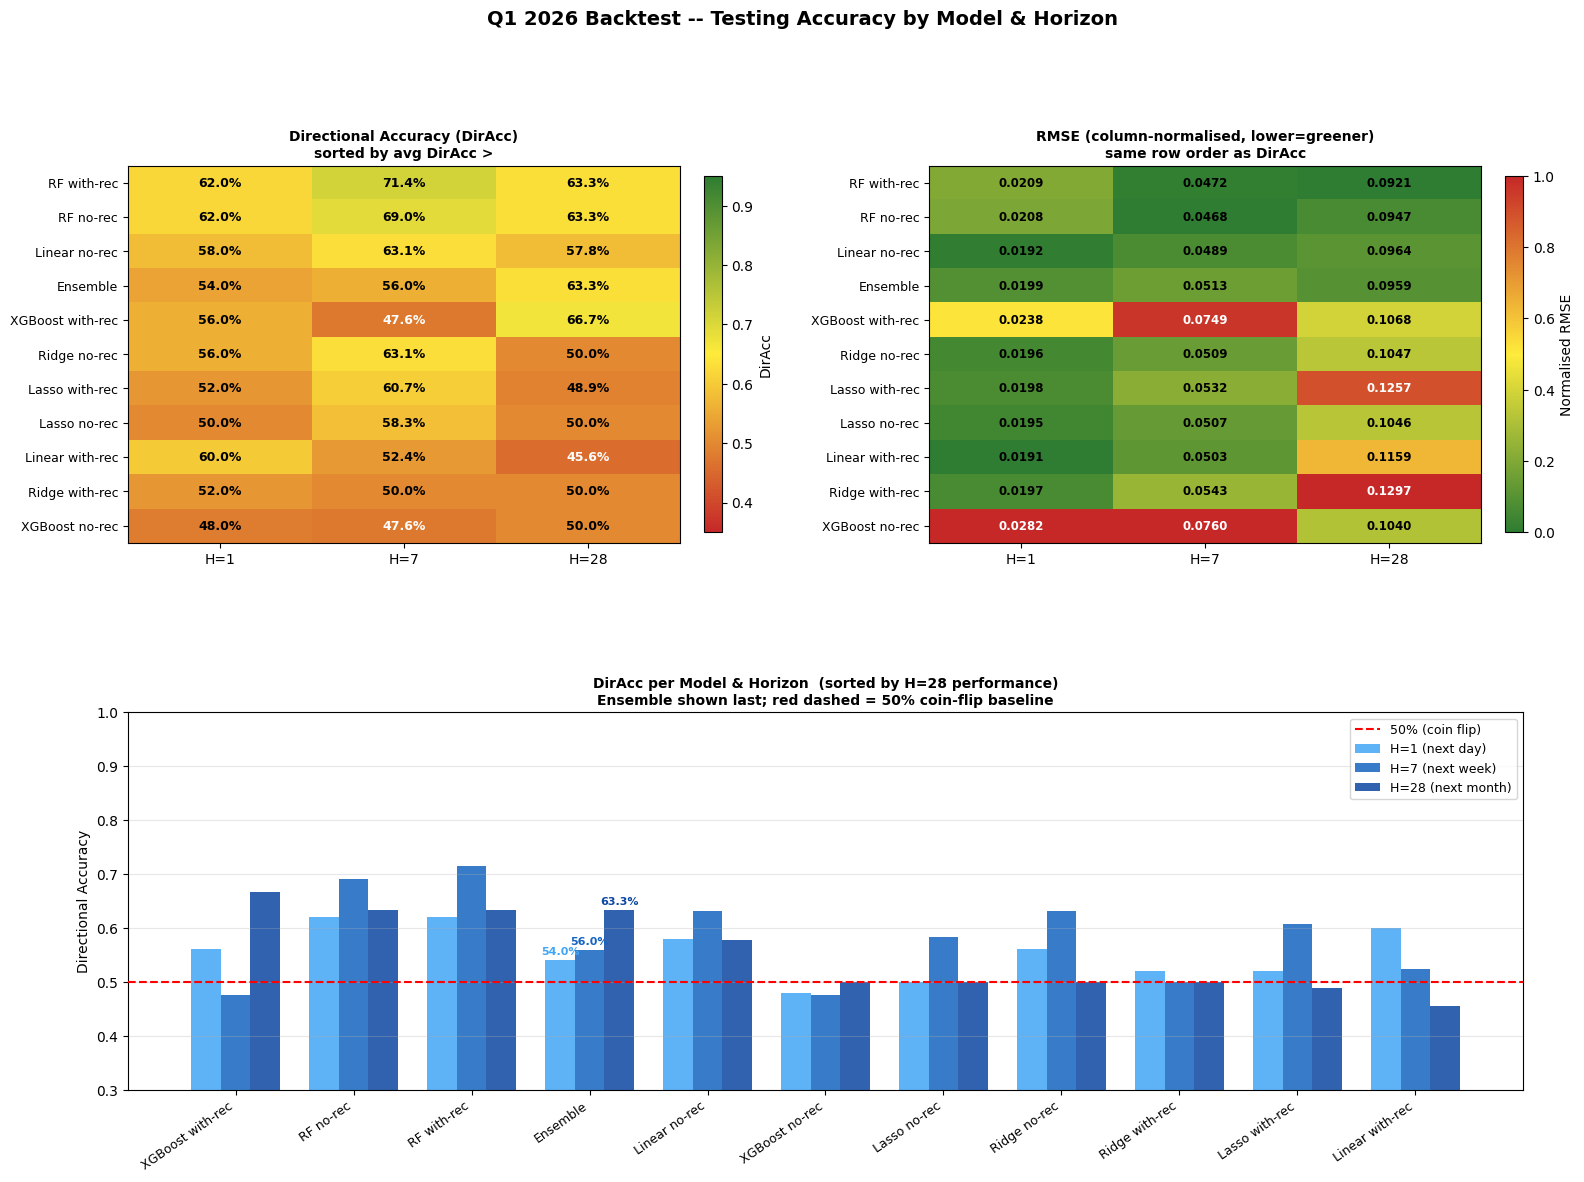

Saved: accuracy_diagram.png


In [8]:
# -- Testing Accuracy Diagram --------------------------------------------------
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

ALL_MODELS = MODEL_KEYS + ['Ensemble']
HORIZONS   = [1, 7, 28]

# Build DirAcc and RMSE matrices  (rows=models, cols=horizons)
da_matrix   = np.array([[diracc_by_model[H][m] for H in HORIZONS] for m in ALL_MODELS])
rmse_matrix = np.array([[rmse_by_model[H][m]   for H in HORIZONS] for m in ALL_MODELS])

# Sort rows by average DirAcc descending
sort_idx  = np.argsort(-da_matrix.mean(axis=1))
da_sorted   = da_matrix[sort_idx]
rmse_sorted = rmse_matrix[sort_idx]
labels_sorted = [ALL_MODELS[i] for i in sort_idx]

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Q1 2026 Backtest -- Testing Accuracy by Model & Horizon',
    fontsize=14, fontweight='bold', y=1.01,
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# -- Panel A: DirAcc heatmap ---------------------------------------------------
ax_heat = fig.add_subplot(gs[0, 0])
cmap_da = mcolors.LinearSegmentedColormap.from_list(
    'acc', ['#C62828', '#FFEB3B', '#2E7D32'], N=256)
im = ax_heat.imshow(da_sorted, cmap=cmap_da, vmin=0.35, vmax=0.95, aspect='auto')
ax_heat.set_xticks(range(3))
ax_heat.set_xticklabels([f'H={H}' for H in HORIZONS], fontsize=10)
ax_heat.set_yticks(range(len(labels_sorted)))
ax_heat.set_yticklabels(labels_sorted, fontsize=9)
ax_heat.set_title('Directional Accuracy (DirAcc)\nsorted by avg DirAcc >', fontsize=10, fontweight='bold')
for r in range(len(labels_sorted)):
    for c in range(3):
        v = da_sorted[r, c]
        txt_color = 'white' if v < 0.48 or v > 0.78 else 'black'
        ax_heat.text(c, r, f'{v:.1%}', ha='center', va='center',
                     fontsize=9, fontweight='bold', color=txt_color)
plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.04, label='DirAcc')

# -- Panel B: RMSE heatmap -----------------------------------------------------
ax_rmse = fig.add_subplot(gs[0, 1])
cmap_rmse = mcolors.LinearSegmentedColormap.from_list(
    'rmse', ['#2E7D32', '#FFEB3B', '#C62828'], N=256)
# Normalise RMSE within each horizon column so colours are comparable
rmse_norm = rmse_sorted.copy()
for c in range(3):
    col = rmse_norm[:, c]
    rmse_norm[:, c] = (col - col.min()) / (col.max() - col.min() + 1e-12)
im2 = ax_rmse.imshow(rmse_norm, cmap=cmap_rmse, vmin=0, vmax=1, aspect='auto')
ax_rmse.set_xticks(range(3))
ax_rmse.set_xticklabels([f'H={H}' for H in HORIZONS], fontsize=10)
ax_rmse.set_yticks(range(len(labels_sorted)))
ax_rmse.set_yticklabels(labels_sorted, fontsize=9)
ax_rmse.set_title('RMSE (column-normalised, lower=greener)\nsame row order as DirAcc', fontsize=10, fontweight='bold')
for r in range(len(labels_sorted)):
    for c in range(3):
        v = rmse_sorted[r, c]
        nv = rmse_norm[r, c]
        txt_color = 'white' if nv > 0.75 else 'black'
        ax_rmse.text(c, r, f'{v:.4f}', ha='center', va='center',
                     fontsize=8.5, fontweight='bold', color=txt_color)
plt.colorbar(im2, ax=ax_rmse, fraction=0.03, pad=0.04, label='Normalised RMSE')

# -- Panel C: DirAcc grouped bar chart ----------------------------------------
ax_bar = fig.add_subplot(gs[1, :])
x      = np.arange(len(ALL_MODELS))
width  = 0.25
bar_colors_h = ['#42A5F5', '#1565C0', '#0D47A1']
h_labels     = ['H=1 (next day)', 'H=7 (next week)', 'H=28 (next month)']

# Sort bars by H=28 DirAcc for readability
sort_bar = np.argsort(-da_matrix[:, 2])
labels_bar = [ALL_MODELS[i] for i in sort_bar]

for hi, H in enumerate(HORIZONS):
    vals = [diracc_by_model[H][m] for m in labels_bar]
    bars = ax_bar.bar(x + hi * width, vals, width, label=h_labels[hi],
                      color=bar_colors_h[hi], alpha=0.85)

ax_bar.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='50% (coin flip)', zorder=5)
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(labels_bar, rotation=35, ha='right', fontsize=9)
ax_bar.set_ylabel('Directional Accuracy', fontsize=10)
ax_bar.set_title(
    'DirAcc per Model & Horizon  (sorted by H=28 performance)\n'
    'Ensemble shown last; red dashed = 50% coin-flip baseline',
    fontsize=10, fontweight='bold',
)
ax_bar.set_ylim(0.3, 1.0)
ax_bar.legend(fontsize=9, loc='upper right')
ax_bar.grid(axis='y', alpha=0.3)

# Annotate ensemble bars
ens_pos = labels_bar.index('Ensemble')
for hi, H in enumerate(HORIZONS):
    v = diracc_by_model[H]['Ensemble']
    ax_bar.annotate(
        f'{v:.1%}',
        xy=(ens_pos + hi * width, v),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=8, color=bar_colors_h[hi], fontweight='bold',
    )

plt.savefig('accuracy_diagram.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: accuracy_diagram.png")

In [9]:
# -- PHASE 2 -- TRAIN: Production XGBoost models -----------------------------
print('Phase 2 -- TRAIN: Fitting production XGBoost models ...')
xgb_preds = {}
for tag, df in [('no_rec', df_norec), ('with_rec', df_full)]:
    for H in [1, 7, 28]:
        X_tr, y_tr, X_pred = build_train_pred(df, H, strict=False, target_date=target_date)
        preds, best_n = fit_xgb_sweep(X_tr, y_tr, X_pred)
        xgb_preds[(tag, H)] = preds[0]
        label      = 'no-rec' if tag == 'no_rec' else 'with-rec'
        input_date = (target_date - pd.Timedelta(days=H)).date()
        print(f'  XGB {label} H={H:2d}: n_est={best_n}  input={input_date}  pred={preds[0]:.4f}')
print('XGBoost production done.')


Phase 2 -- TRAIN: Fitting production XGBoost models ...
  XGB no-rec H= 1: n_est=63  input=2026-05-15  pred=1.6502
  XGB no-rec H= 7: n_est=56  input=2026-05-09  pred=1.6947
  XGB no-rec H=28: n_est=42  input=2026-04-18  pred=1.7728
  XGB with-rec H= 1: n_est=122  input=2026-05-15  pred=1.6256
  XGB with-rec H= 7: n_est=114  input=2026-05-09  pred=1.6505
  XGB with-rec H=28: n_est=11  input=2026-04-18  pred=2.0965
XGBoost production done.


In [10]:
# -- PHASE 2 -- TRAIN: Production Random Forest models -----------------------
print('Fitting production Random Forest models ...')
rf_preds = {}
for tag, df in [('no_rec', df_norec), ('with_rec', df_full)]:
    for H in [1, 7, 28]:
        X_tr, y_tr, X_pred = build_train_pred(df, H, strict=True, target_date=target_date)
        preds = fit_rf(X_tr, y_tr, X_pred)
        rf_preds[(tag, H)] = preds[0]
        label      = 'no-rec' if tag == 'no_rec' else 'with-rec'
        input_date = (target_date - pd.Timedelta(days=H)).date()
        print(f'  RF {label} H={H:2d}: input={input_date}  pred={preds[0]:.4f}')
print('RF production done.')


Fitting production Random Forest models ...
  RF no-rec H= 1: input=2026-05-15  pred=1.6188
  RF no-rec H= 7: input=2026-05-09  pred=1.6240
  RF no-rec H=28: input=2026-04-18  pred=1.6250
  RF with-rec H= 1: input=2026-05-15  pred=1.6191
  RF with-rec H= 7: input=2026-05-09  pred=1.6235
  RF with-rec H=28: input=2026-04-18  pred=1.6279
RF production done.


In [11]:
# -- PHASE 2 -- TRAIN: Production Linear models ------------------------------
print('Fitting production Linear models ...')
linear_preds = {}
for tag, df in [('no_rec', df_norec), ('with_rec', df_full)]:
    for H in [1, 7, 28]:
        X_tr, y_tr, X_pred = build_train_pred(df, H, strict=True, target_date=target_date)
        res = fit_linear(X_tr, y_tr, X_pred)
        for mname, p in res.items():
            linear_preds[(mname, tag, H)] = p[0]
        label      = 'no-rec' if tag == 'no_rec' else 'with-rec'
        input_date = (target_date - pd.Timedelta(days=H)).date()
        r, la, li  = res['Ridge'][0], res['Lasso'][0], res['Linear'][0]
        print(f'  Linear {label} H={H:2d}: input={input_date}  Ridge={r:.4f}  Lasso={la:.4f}  Linear={li:.4f}')
print('Linear production done.')


Fitting production Linear models ...
  Linear no-rec H= 1: input=2026-05-15  Ridge=1.6210  Lasso=1.6210  Linear=1.6199
  Linear no-rec H= 7: input=2026-05-09  Ridge=1.6323  Lasso=1.6370  Linear=1.6360
  Linear no-rec H=28: input=2026-04-18  Ridge=1.6404  Lasso=1.6356  Linear=1.6490
  Linear with-rec H= 1: input=2026-05-15  Ridge=1.6209  Lasso=1.6200  Linear=1.6195
  Linear with-rec H= 7: input=2026-05-09  Ridge=1.6359  Lasso=1.6499  Linear=1.6423
  Linear with-rec H=28: input=2026-04-18  Ridge=1.6297  Lasso=1.6788  Linear=1.6516
Linear production done.


In [12]:
print('=' * 70)
print(f'  BAA10Y SPREAD PREDICTION FOR {target_date.date()}')
print(f'  Current spread: {current_spread:.4f}  (as of {current_date.date()})')
print('=' * 70)
print('  Weighting: direction-conditional precision from Q4 2025 backtest')
print('  (if model says UP, weight = how often it was right saying UP; same for DOWN)')

for H in [1, 7, 28]:
    input_date = (target_date - pd.Timedelta(days=H)).date()
    model_preds_h = [
        xgb_preds[('no_rec',  H)], xgb_preds[('with_rec', H)],
        rf_preds[('no_rec',   H)], rf_preds[('with_rec',  H)],
        linear_preds[('Ridge',  'no_rec',  H)], linear_preds[('Lasso',  'no_rec',  H)],
        linear_preds[('Linear', 'no_rec',  H)],
        linear_preds[('Ridge',  'with_rec', H)], linear_preds[('Lasso',  'with_rec', H)],
        linear_preds[('Linear', 'with_rec', H)],
    ]

    rows = []
    weighted_sum, total_w = 0.0, 0.0
    for mname, pred in zip(MODEL_KEYS, model_preds_h):
        pred_dir = 'UP' if pred >= current_spread else 'DOWN'
        w_key    = 'up' if pred >= current_spread else 'down'
        prec     = model_precision[H][mname][w_key]
        weighted_sum += pred * prec
        total_w      += prec
        rows.append((mname, pred, pred_dir, f'{prec:.2%}'))

    ensemble  = weighted_sum / total_w if total_w > 0 else np.mean(model_preds_h)
    delta     = ensemble - current_spread
    direction = 'UP' if delta > 0 else 'DOWN'

    df_res = pd.DataFrame(rows, columns=['Model', 'Pred Spread', 'Pred Dir', 'Precision Weight'])
    print(f'\n=== H={H:2d} day(s)  |  input features: {input_date}  ->  target: {target_date.date()} ===')
    print(df_res.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print(f'\n  Naive (unchanged):              {current_spread:.4f}')
    print(f'  Precision-weighted ensemble:    {ensemble:.4f}  ({direction}, delta={delta:+.4f})')

  BAA10Y SPREAD PREDICTION FOR 2026-05-16
  Current spread: 1.6200  (as of 2026-05-18)
  Weighting: direction-conditional precision from Q4 2025 backtest
  (if model says UP, weight = how often it was right saying UP; same for DOWN)

=== H= 1 day(s)  |  input features: 2026-05-15  ->  target: 2026-05-16 ===
           Model  Pred Spread Pred Dir Precision Weight
  XGBoost no-rec       1.6502       UP           27.59%
XGBoost with-rec       1.6256       UP           30.67%
       RF no-rec       1.6188     DOWN           43.48%
     RF with-rec       1.6191     DOWN           37.50%
    Ridge no-rec       1.6210       UP           30.99%
    Lasso no-rec       1.6210       UP           27.78%
   Linear no-rec       1.6199     DOWN           32.26%
  Ridge with-rec       1.6209       UP           30.67%
  Lasso with-rec       1.6200       UP           29.41%
 Linear with-rec       1.6195     DOWN           34.09%

  Naive (unchanged):              1.6200
  Precision-weighted ensemble:   

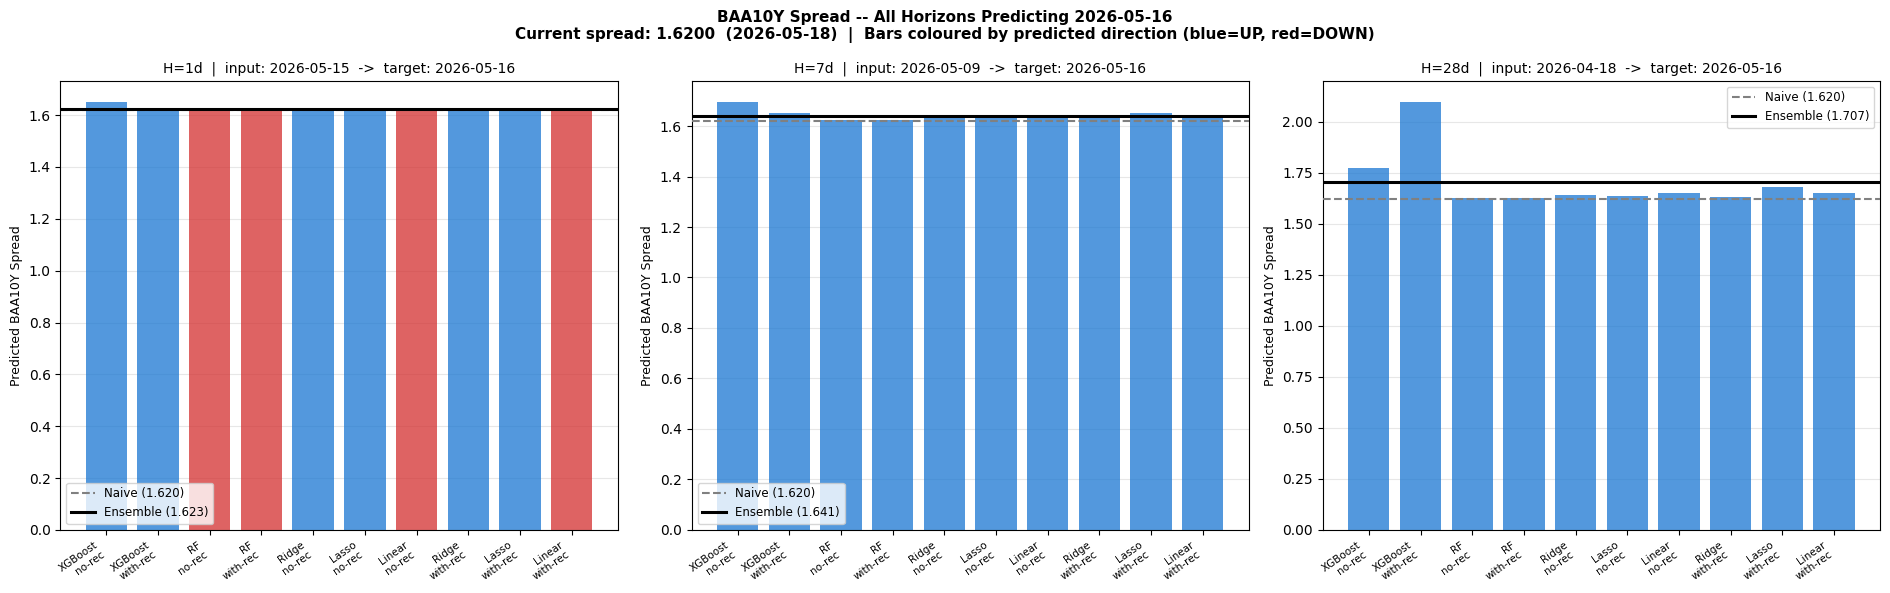

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle(
    f'BAA10Y Spread -- All Horizons Predicting {target_date.date()}\n'
    f'Current spread: {current_spread:.4f}  ({current_date.date()})'
    f'  |  Bars coloured by predicted direction (blue=UP, red=DOWN)',
    fontsize=11, fontweight='bold',
)

model_labels = [
    'XGBoost\nno-rec', 'XGBoost\nwith-rec',
    'RF\nno-rec',       'RF\nwith-rec',
    'Ridge\nno-rec',    'Lasso\nno-rec',   'Linear\nno-rec',
    'Ridge\nwith-rec',  'Lasso\nwith-rec', 'Linear\nwith-rec',
]

for ax, H in zip(axes, [1, 7, 28]):
    input_date = (target_date - pd.Timedelta(days=H)).date()
    model_preds_h = [
        xgb_preds[('no_rec',  H)], xgb_preds[('with_rec', H)],
        rf_preds[('no_rec',   H)], rf_preds[('with_rec',  H)],
        linear_preds[('Ridge',  'no_rec',  H)], linear_preds[('Lasso',  'no_rec',  H)],
        linear_preds[('Linear', 'no_rec',  H)],
        linear_preds[('Ridge',  'with_rec', H)], linear_preds[('Lasso',  'with_rec', H)],
        linear_preds[('Linear', 'with_rec', H)],
    ]

    # Direction-conditional precision ensemble
    weighted_sum, total_w = 0.0, 0.0
    bar_colors = []
    for mname, pred in zip(MODEL_KEYS, model_preds_h):
        is_up  = pred >= current_spread
        w_key  = 'up' if is_up else 'down'
        prec   = model_precision[H][mname][w_key]
        weighted_sum += pred * prec
        total_w      += prec
        bar_colors.append('#1976D2' if is_up else '#D32F2F')
    ensemble = weighted_sum / total_w if total_w > 0 else np.mean(model_preds_h)

    ax.bar(range(10), model_preds_h, color=bar_colors, alpha=0.75, zorder=2)
    ax.axhline(current_spread, color='gray',  linestyle='--', linewidth=1.5,
               label=f'Naive ({current_spread:.3f})', zorder=3)
    ax.axhline(ensemble, color='black', linestyle='-', linewidth=2.2,
               label=f'Ensemble ({ensemble:.3f})', zorder=3)
    ax.set_xticks(range(10))
    ax.set_xticklabels(model_labels, fontsize=7.5, rotation=35, ha='right')
    ax.set_title(f'H={H}d  |  input: {input_date}  ->  target: {target_date.date()}', fontsize=10)
    ax.set_ylabel('Predicted BAA10Y Spread', fontsize=9)
    ax.legend(fontsize=8.5)
    ax.grid(axis='y', alpha=0.3, zorder=1)

plt.tight_layout()
plt.show()